In [3]:
import json, glob, os
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

def find_results_dir(start=None):
    start = Path(start or os.getcwd()).resolve()
    for base in [start, *start.parents]:
        for rel in ['scripts/Results', 'omicsdrp/scripts/Results', 'Results']:
            p = base / rel
            if p.is_dir():
                return str(p)
    raise FileNotFoundError('Results dir not found from ' + str(start))

RESULTS_DIR = find_results_dir()
print('RESULTS_DIR =', RESULTS_DIR)

RESULTS_DIR = /project/OmicsDRP_Review/omicsdrp/scripts/Results


## Summary Table

In [4]:
METRICS = ['rmse', 'mae', 'r2', 'pearson', 'spearman']
OMICS_ORDER = ['SNP', 'MET', 'CNV', 'RNA']

def load_fold_records(results_dir):
    rows = []
    for cfg_path in sorted(glob.glob(os.path.join(results_dir, '*', 'config.json'))):
        d = os.path.dirname(cfg_path)
        fold_jsons = sorted(glob.glob(os.path.join(d, 'folds', 'fold_*_test_metrics.json')))
        if not fold_jsons:
            continue  # no completed folds yet
        cfg = json.load(open(cfg_path))
        omics_str = '+'.join([o for o in OMICS_ORDER if o in cfg['omics']])
        for fj in fold_jsons:
            r = json.load(open(fj))
            rec = {'split_mode': cfg['split_mode'], 'omics': omics_str,
                   'cell': cfg['cell_encoder'], 'drug': cfg['drug_encoder'],
                   'tag': os.path.basename(d), 'fold': int(r.get('fold', -1)),
                   'best_epoch': r.get('best_epoch')}
            for m in METRICS:
                rec[m] = r.get(m, np.nan)
            rows.append(rec)
    return pd.DataFrame(rows)

folds = load_fold_records(RESULTS_DIR)
print(f"{folds['tag'].nunique()} experiments, {len(folds)} fold-records")
folds.groupby('split_mode')['tag'].nunique().rename('experiments')

36 experiments, 180 fold-records


split_mode
mixed          12
unseen_cell    12
unseen_drug    12
Name: experiments, dtype: int64

In [5]:
COND = ['split_mode', 'omics', 'cell', 'drug']

agg = folds.groupby(COND)[METRICS].agg(['mean', 'std', 'median', 'min', 'max'])
agg.columns = [f'{m}_{s}' for m, s in agg.columns]
agg = agg.join(folds.groupby(COND)['fold'].nunique().rename('n_folds')).reset_index()
agg = agg.sort_values(['split_mode', 'rmse_mean']).reset_index(drop=True)
print('conditions:', len(agg))
agg.round(4)

conditions: 36


,split_mode,omics,cell,drug,rmse_mean,rmse_std,rmse_median,rmse_min,rmse_max,mae_mean,mae_std,mae_median,mae_min,mae_max,r2_mean,r2_std,r2_median,r2_min,r2_max,pearson_mean,pearson_std,pearson_median,pearson_min,pearson_max,spearman_mean,spearman_std,spearman_median,spearman_min,spearman_max,n_folds
0,mixed,SNP+MET+CNV+RNA,attention,morgan,0.9652,0.0235,0.9644,0.9380,0.9933,0.7156,0.0177,0.7191,0.6965,0.7332,0.8834,0.0065,0.8848,0.8750,0.8900,0.9401,0.0035,0.9411,0.9357,0.9435,0.9143,0.0038,0.9159,0.9101,0.9182,5
1,mixed,CNV+RNA,attention,morgan,0.9662,0.0116,0.9717,0.9531,0.9762,0.7160,0.0088,0.7183,0.7067,0.7249,0.8832,0.0038,0.8820,0.8794,0.8873,0.9399,0.0020,0.9393,0.9378,0.9420,0.9139,0.0019,0.9130,0.9123,0.9169,5
2,mixed,SNP+MET+CNV+RNA,attention,unimol,0.9671,0.0118,0.9621,0.9582,0.9874,0.7187,0.0099,0.7188,0.7048,0.7329,0.8830,0.0033,0.8843,0.8773,0.8853,0.9399,0.0019,0.9406,0.9367,0.9413,0.9139,0.0025,0.9149,0.9096,0.9158,5
3,mixed,SNP+MET+CNV+RNA,attention,molformer,0.9688,0.0083,0.9646,0.9617,0.9824,0.7171,0.0060,0.7179,0.7107,0.7239,0.8826,0.0029,0.8836,0.8778,0.8848,0.9398,0.0015,0.9404,0.9371,0.9408,0.9139,0.0017,0.9141,0.9112,0.9158,5
4,mixed,SNP+MET+CNV+RNA,attention,chemberta,0.9693,0.0150,0.9669,0.9531,0.9929,0.7216,0.0104,0.7187,0.7087,0.7361,0.8824,0.0046,0.8838,0.8751,0.8865,0.9396,0.0024,0.9403,0.9356,0.9415,0.9134,0.0027,0.9131,0.9093,0.9161,5
5,mixed,MET+RNA,attention,morgan,0.9700,0.0122,0.9640,0.9589,0.9850,0.7206,0.0052,0.7182,0.7151,0.7269,0.8822,0.0040,0.8846,0.8771,0.8858,0.9395,0.0022,0.9408,0.9367,0.9415,0.9129,0.0022,0.9141,0.9105,0.9148,5
6,mixed,SNP+MET+RNA,attention,morgan,0.9701,0.0049,0.9701,0.9632,0.9764,0.7201,0.0080,0.7234,0.7098,0.7282,0.8823,0.0011,0.8830,0.8809,0.8832,0.9394,0.0006,0.9397,0.9386,0.9399,0.9132,0.0011,0.9138,0.9120,0.9142,5
7,mixed,SNP+RNA,attention,morgan,0.9709,0.0100,0.9705,0.9601,0.9813,0.7183,0.0038,0.7177,0.7125,0.7220,0.8820,0.0034,0.8830,0.8782,0.8859,0.9393,0.0018,0.9399,0.9373,0.9413,0.9131,0.0019,0.9121,0.9116,0.9159,5
8,mixed,SNP+MET+CNV+RNA,attention,graphormer,0.9722,0.0024,0.9713,0.9694,0.9756,0.7218,0.0039,0.7213,0.7168,0.7268,0.8817,0.0015,0.8822,0.8794,0.8832,0.9393,0.0009,0.9397,0.9379,0.9400,0.9131,0.0007,0.9131,0.9120,0.9138,5
9,mixed,SNP+CNV+RNA,attention,morgan,0.9739,0.0144,0.9742,0.9602,0.9961,0.7235,0.0119,0.7202,0.7139,0.7429,0.8813,0.0042,0.8825,0.8751,0.8850,0.9390,0.0022,0.9397,0.9357,0.9409,0.9126,0.0026,0.9137,0.9082,0.9146,5


In [6]:
BASE = dict(omics='SNP+MET+CNV+RNA', cell='attention', drug='morgan')

for sm in ['mixed', 'unseen_cell', 'unseen_drug']:
    if sm not in agg['split_mode'].values:
        continue
    for vary, title in [('omics', 'FEATURE (omics)'), ('cell', 'CELL ENCODER'), ('drug', 'DRUG REP')]:
        sub = agg[agg['split_mode'] == sm].copy()
        fixed = {k: v for k, v in BASE.items() if k != vary}
        for k, v in fixed.items():
            sub = sub[sub[k] == v]
        if len(v) <= 1:
            continue
        print(f'\n--- {sm} | {title} ablation ---')
        display(sub)
        sub.to_csv(f"./outputs/{sm}_{vary}.csv", index=False)


--- mixed | FEATURE (omics) ablation ---


,split_mode,omics,cell,drug,rmse_mean,rmse_std,rmse_median,rmse_min,rmse_max,mae_mean,mae_std,mae_median,mae_min,mae_max,r2_mean,r2_std,r2_median,r2_min,r2_max,pearson_mean,pearson_std,pearson_median,pearson_min,pearson_max,spearman_mean,spearman_std,spearman_median,spearman_min,spearman_max,n_folds
0,mixed,SNP+MET+CNV+RNA,attention,morgan,0.965189,0.023546,0.964439,0.938022,0.993279,0.715577,0.017651,0.719119,0.696456,0.733162,0.883355,0.006543,0.884826,0.875038,0.890040,0.940137,0.003501,0.941090,0.935689,0.943499,0.914338,0.003752,0.915869,0.910143,0.918182,5
1,mixed,CNV+RNA,attention,morgan,0.966166,0.011629,0.971653,0.953075,0.976176,0.716022,0.008822,0.718347,0.706668,0.724894,0.883173,0.003814,0.882014,0.879388,0.887284,0.939909,0.001992,0.939311,0.937758,0.942036,0.913933,0.001887,0.912976,0.912256,0.916905,5
5,mixed,MET+RNA,attention,morgan,0.969973,0.012165,0.963978,0.958927,0.984988,0.720600,0.005186,0.718207,0.715123,0.726862,0.882248,0.003980,0.884628,0.877115,0.885753,0.939512,0.002238,0.940771,0.936738,0.941523,0.912942,0.002202,0.914052,0.910467,0.914834,5
6,mixed,SNP+MET+RNA,attention,morgan,0.970055,0.004854,0.970118,0.963229,0.976412,0.720126,0.007980,0.723399,0.709825,0.728220,0.882265,0.001128,0.882977,0.880855,0.883196,0.939378,0.000599,0.939690,0.938640,0.939944,0.913214,0.001058,0.913817,0.912032,0.914230,5
7,mixed,SNP+RNA,attention,morgan,0.970854,0.010020,0.970451,0.960080,0.981324,0.718263,0.003849,0.717698,0.712496,0.722036,0.882044,0.003406,0.882991,0.878213,0.885865,0.939306,0.001804,0.939881,0.937333,0.941306,0.913091,0.001853,0.912063,0.911602,0.915910,5
9,mixed,SNP+CNV+RNA,attention,morgan,0.973861,0.014367,0.974215,0.960240,0.996092,0.723476,0.011863,0.720209,0.713937,0.742935,0.881304,0.004186,0.882479,0.875090,0.884992,0.938985,0.002189,0.939695,0.935726,0.940882,0.912577,0.002566,0.913701,0.908198,0.914648,5
10,mixed,MET+CNV+RNA,attention,morgan,0.974698,0.015511,0.981166,0.955200,0.992436,0.722729,0.013727,0.724183,0.706483,0.737433,0.881085,0.004745,0.879692,0.876005,0.887022,0.938882,0.002455,0.938225,0.935956,0.941894,0.912368,0.002927,0.911456,0.908699,0.916330,5



--- mixed | CELL ENCODER ablation ---


,split_mode,omics,cell,drug,rmse_mean,rmse_std,rmse_median,rmse_min,rmse_max,mae_mean,mae_std,mae_median,mae_min,mae_max,r2_mean,r2_std,r2_median,r2_min,r2_max,pearson_mean,pearson_std,pearson_median,pearson_min,pearson_max,spearman_mean,spearman_std,spearman_median,spearman_min,spearman_max,n_folds
0,mixed,SNP+MET+CNV+RNA,attention,morgan,0.965189,0.023546,0.964439,0.938022,0.993279,0.715577,0.017651,0.719119,0.696456,0.733162,0.883355,0.006543,0.884826,0.875038,0.890040,0.940137,0.003501,0.941090,0.935689,0.943499,0.914338,0.003752,0.915869,0.910143,0.918182,5
11,mixed,SNP+MET+CNV+RNA,mlp,morgan,0.993427,0.018317,0.992313,0.970409,1.015098,0.736992,0.012413,0.733845,0.721967,0.751502,0.876472,0.005189,0.876035,0.869487,0.882316,0.936400,0.002766,0.936217,0.932627,0.939588,0.908560,0.003399,0.909240,0.905016,0.912762,5



--- mixed | DRUG REP ablation ---


...

,split_mode,omics,cell,drug,rmse_mean,rmse_std,rmse_median,rmse_min,rmse_max,mae_mean,mae_std,mae_median,mae_min,mae_max,r2_mean,r2_std,r2_median,r2_min,r2_max,pearson_mean,pearson_std,pearson_median,pearson_min,pearson_max,spearman_mean,spearman_std,spearman_median,spearman_min,spearman_max,n_folds
28,unseen_drug,MET+RNA,attention,morgan,2.647845,0.340453,2.672938,2.179929,3.112380,1.977473,0.219556,1.984205,1.683701,2.286220,0.104389,0.170345,0.037732,-0.068099,0.344296,0.430152,0.136170,0.382793,0.287449,0.628618,0.385344,0.113565,0.443307,0.245237,0.500487,5
29,unseen_drug,SNP+RNA,attention,morgan,2.648931,0.293374,2.651507,2.290663,3.046834,1.997474,0.180083,2.008708,1.777345,2.260619,0.103991,0.149721,0.053101,-0.036296,0.275989,0.425760,0.132756,0.359830,0.305784,0.603738,0.375351,0.107561,0.409049,0.254592,0.485328,5
30,unseen_drug,SNP+MET+CNV+RNA,attention,morgan,2.653013,0.246274,2.652094,2.412752,3.021565,1.987245,0.143640,1.956759,1.869886,2.221681,0.102395,0.118508,0.052681,-0.006677,0.258765,0.422604,0.101387,0.385569,0.323010,0.533466,0.381834,0.089551,0.396346,0.267468,0.471877,5
31,unseen_drug,SNP+MET+RNA,attention,morgan,2.660542,0.293101,2.687030,2.310889,3.100672,1.965868,0.171911,1.936644,1.777322,2.245650,0.097493,0.139313,0.032089,-0.060078,0.263147,0.424505,0.123709,0.373959,0.305307,0.606228,0.370498,0.088896,0.427834,0.263321,0.440958,5
32,unseen_drug,SNP+CNV+RNA,attention,morgan,2.673381,0.222916,2.711662,2.420891,2.995231,1.973325,0.146270,1.953652,1.825063,2.199982,0.088796,0.107583,0.025411,-0.003414,0.219865,0.424715,0.108093,0.377864,0.334338,0.574635,0.374587,0.071734,0.393082,0.274782,0.449042,5
33,unseen_drug,MET+CNV+RNA,attention,morgan,2.680226,0.275557,2.667115,2.376750,3.046954,1.994632,0.163024,1.950860,1.844183,2.227223,0.082501,0.146017,0.041920,-0.076352,0.250056,0.417449,0.105238,0.363292,0.326505,0.539722,0.381797,0.091622,0.408944,0.257823,0.484247,5
34,unseen_drug,CNV+RNA,attention,morgan,2.691267,0.235475,2.608988,2.505992,3.074713,2.015166,0.144632,1.954419,1.902047,2.254589,0.077503,0.103428,0.083226,-0.042403,0.215129,0.418335,0.096233,0.395242,0.310108,0.531828,0.370657,0.093876,0.392587,0.265704,0.464417,5



--- unseen_drug | CELL ENCODER ablation ---


,split_mode,omics,cell,drug,rmse_mean,rmse_std,rmse_median,rmse_min,rmse_max,mae_mean,mae_std,mae_median,mae_min,mae_max,r2_mean,r2_std,r2_median,r2_min,r2_max,pearson_mean,pearson_std,pearson_median,pearson_min,pearson_max,spearman_mean,spearman_std,spearman_median,spearman_min,spearman_max,n_folds
27,unseen_drug,SNP+MET+CNV+RNA,mlp,morgan,2.615750,0.247222,2.654092,2.348647,2.982585,1.978659,0.159887,1.971647,1.820970,2.240685,0.127486,0.117117,0.066354,0.019129,0.268994,0.444891,0.108339,0.380299,0.341954,0.583140,0.399559,0.083897,0.435531,0.289218,0.490599,5
30,unseen_drug,SNP+MET+CNV+RNA,attention,morgan,2.653013,0.246274,2.652094,2.412752,3.021565,1.987245,0.143640,1.956759,1.869886,2.221681,0.102395,0.118508,0.052681,-0.006677,0.258765,0.422604,0.101387,0.385569,0.323010,0.533466,0.381834,0.089551,0.396346,0.267468,0.471877,5



--- unseen_drug | DRUG REP ablation ---


,split_mode,omics,cell,drug,rmse_mean,rmse_std,rmse_median,rmse_min,rmse_max,mae_mean,mae_std,mae_median,mae_min,mae_max,r2_mean,r2_std,r2_median,r2_min,r2_max,pearson_mean,pearson_std,pearson_median,pearson_min,pearson_max,spearman_mean,spearman_std,spearman_median,spearman_min,spearman_max,n_folds
24,unseen_drug,SNP+MET+CNV+RNA,attention,chemberta,2.535465,0.141020,2.526569,2.342286,2.674932,1.911027,0.070442,1.937196,1.790730,1.967394,0.179684,0.079776,0.209299,0.051634,0.261079,0.505137,0.072184,0.530815,0.378717,0.550574,0.478064,0.071334,0.496853,0.356708,0.531962,5
25,unseen_drug,SNP+MET+CNV+RNA,attention,molformer,2.536347,0.197207,2.587052,2.199733,2.717345,1.920020,0.149795,1.958697,1.742599,2.082886,0.179923,0.090277,0.152695,0.112924,0.332328,0.495408,0.065278,0.470414,0.444147,0.608166,0.437316,0.049465,0.423593,0.385211,0.499290,5
26,unseen_drug,SNP+MET+CNV+RNA,attention,unimol,2.572292,0.250837,2.457634,2.371441,2.987304,1.959469,0.205954,1.863428,1.795541,2.310155,0.159356,0.086279,0.186510,0.016023,0.224025,0.447331,0.064987,0.466491,0.335812,0.494384,0.437909,0.072838,0.477156,0.323458,0.497544,5
30,unseen_drug,SNP+MET+CNV+RNA,attention,morgan,2.653013,0.246274,2.652094,2.412752,3.021565,1.987245,0.143640,1.956759,1.869886,2.221681,0.102395,0.118508,0.052681,-0.006677,0.258765,0.422604,0.101387,0.385569,0.323010,0.533466,0.381834,0.089551,0.396346,0.267468,0.471877,5
35,unseen_drug,SNP+MET+CNV+RNA,attention,graphormer,2.696478,0.159036,2.757958,2.459547,2.833271,2.045458,0.045485,2.074763,1.985427,2.081605,0.069345,0.125080,0.155299,-0.071214,0.165295,0.432607,0.089177,0.468345,0.332554,0.534776,0.402634,0.063836,0.394581,0.316123,0.465779,5


In [7]:
os.makedirs('outputs', exist_ok=True)
folds.to_csv('outputs/cv_fold_records.csv', index=False)
agg.round(6).to_csv('outputs/cv_summary_by_condition.csv', index=False)
print('saved:', os.path.abspath('outputs/cv_summary_by_condition.csv'))
print('      ', os.path.abspath('outputs/cv_fold_records.csv'))

saved: /project/OmicsDRP_Review/omicsdrp/notebooks/outputs/cv_summary_by_condition.csv
       /project/OmicsDRP_Review/omicsdrp/notebooks/outputs/cv_fold_records.csv


## Visualization

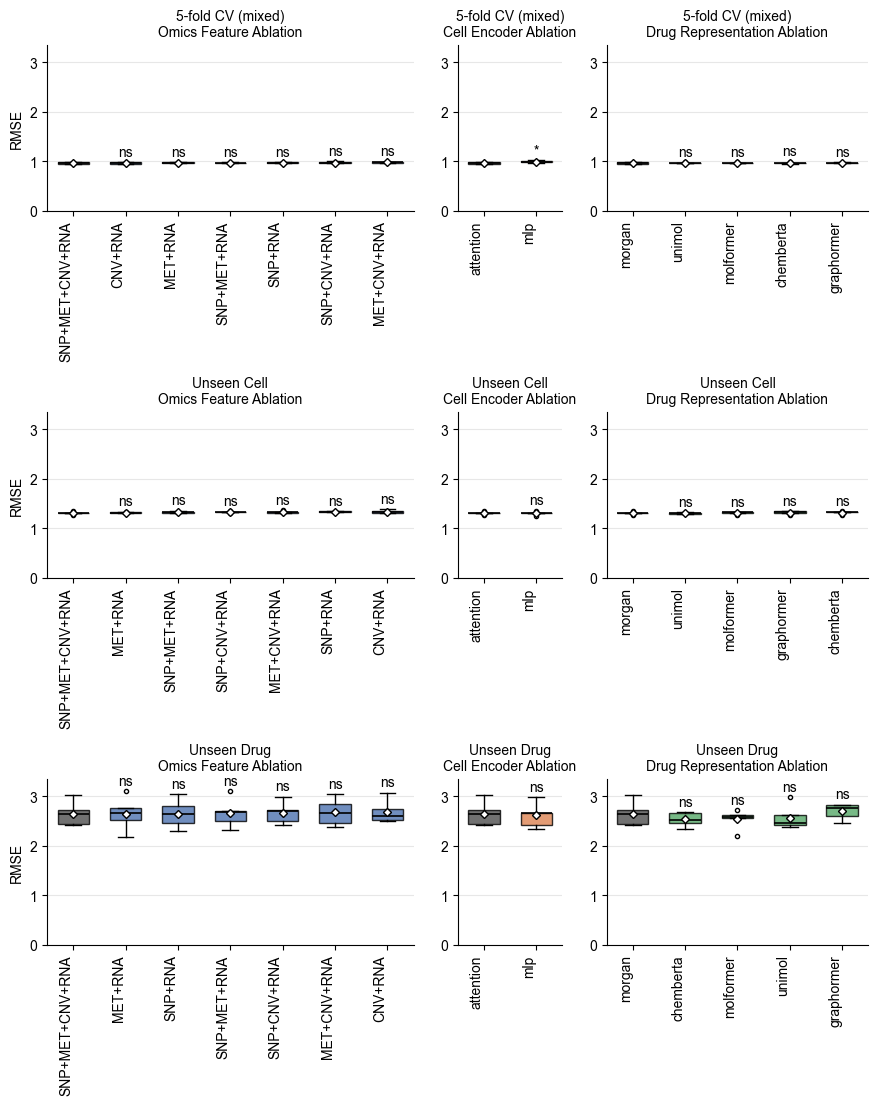

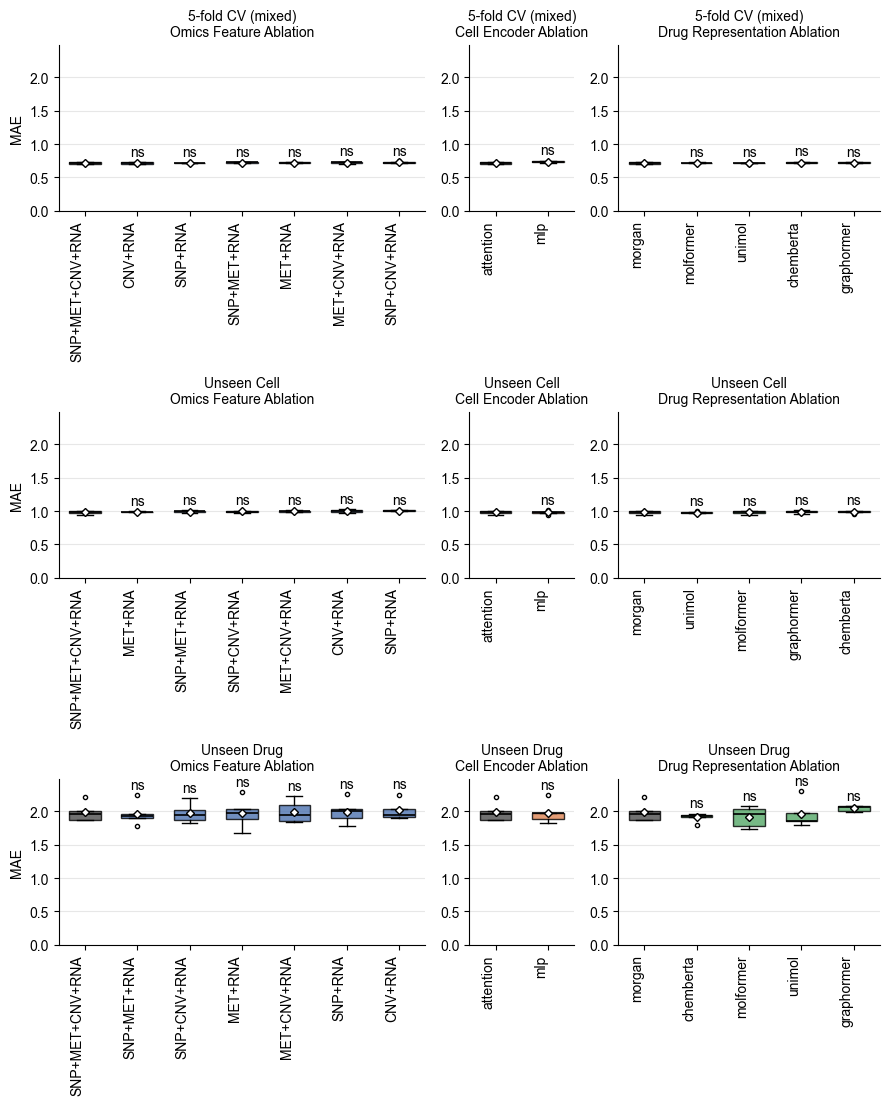

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'font.family': 'Arial',
                     'axes.spines.top': False,
                     'axes.spines.right': False})

# metric -> lower_better
METRICS_TO_PLOT = {'rmse': True, 'mae': True, 'r2': False, 'pearson': False, 'spearman': False}
METRIC_LABEL = {'rmse': 'RMSE', 'mae': 'MAE', 'r2': 'R²', 'pearson': 'Pearson $r$', 'spearman': 'Spearman $\\rho$'}

SPLIT_ORDER = ['mixed', 'unseen_cell', 'unseen_drug']
SPLIT_LABEL = {'mixed': '5-fold CV (mixed)', 'unseen_cell': 'Unseen Cell', 'unseen_drug': 'Unseen Drug'}
ABLATIONS = [
    ('omics', 'Omics Feature Ablation'),
    ('cell', 'Cell Encoder Ablation'),
    ('drug', 'Drug Representation Ablation'),
]
COLORS = {'omics': '#4C72B0', 'cell': '#DD8452', 'drug': '#55A868'}
BASELINE_COLOR = '#4d4d4d'


def stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def plot_ablation_grid(metric, lower_better):
    present_splits = [s for s in SPLIT_ORDER if s in folds['split_mode'].unique()]
    fig, axes = plt.subplots(len(present_splits), len(ABLATIONS),
                              figsize=(9, 4 * len(present_splits)), squeeze=False, width_ratios=[7, 2, 5])

    stat_rows = []
    grid_data = {}
    fig_lo, fig_hi = 0.0, None
    for i, sm in enumerate(present_splits):
        for j, (vary, title) in enumerate(ABLATIONS):
            fixed = {k: v for k, v in BASE.items() if k != vary}
            sub_folds = folds[folds['split_mode'] == sm]
            for k, v in fixed.items():
                sub_folds = sub_folds[sub_folds[k] == v]
            if sub_folds.empty:
                grid_data[(i, j)] = None
                continue

            order = sub_folds.groupby(vary)[metric].mean().sort_values(ascending=lower_better).index.tolist()
            base_val = BASE[vary]
            if base_val in order:
                order.remove(base_val)
                order = [base_val] + order

            baseline_vals = sub_folds[sub_folds[vary] == base_val].sort_values('fold')[metric].values
            box_vals, colors, sig_labels = [], [], []
            for lvl in order:
                vals = sub_folds[sub_folds[vary] == lvl].sort_values('fold')[metric].values
                box_vals.append(vals)
                colors.append(BASELINE_COLOR if lvl == base_val else COLORS[vary])
                if lvl == base_val or len(vals) != len(baseline_vals):
                    sig_labels.append('')
                else:
                    _, p = stats.ttest_rel(vals, baseline_vals)
                    stat_rows.append({'split_mode': sm, 'ablation': vary, 'level': lvl,
                                       'baseline': base_val, 'metric': metric,
                                       'p_value': p, 'stars': stars(p)})
                    sig_labels.append(stars(p))

            grid_data[(i, j)] = dict(order=order, box_vals=box_vals, colors=colors,
                                      sig_labels=sig_labels, title=title)
            hi = max(v.max() for v in box_vals)
            lo = min(v.min() for v in box_vals)
            fig_hi = hi if fig_hi is None else max(fig_hi, hi)
            fig_lo = min(fig_lo, lo)

    if fig_hi is None:
        return pd.DataFrame(stat_rows)
    pad = 0.08 * (fig_hi - fig_lo if fig_hi > fig_lo else abs(fig_hi) or 1)
    ylim = (fig_lo - pad if fig_lo < 0 else 0.0, fig_hi + pad)

    for i, sm in enumerate(present_splits):
        for j, (vary, title) in enumerate(ABLATIONS):
            ax = axes[i][j]
            data = grid_data[(i, j)]
            if data is None:
                ax.axis('off')
                continue
            order, box_vals, colors, sig_labels = (data['order'], data['box_vals'],
                                                     data['colors'], data['sig_labels'])
            x = np.arange(len(order))
            bp = ax.boxplot(box_vals, positions=x, widths=0.6, patch_artist=True,
                             showmeans=True, meanprops=dict(marker='D', markerfacecolor='white',
                                                             markeredgecolor='black', markersize=4),
                             medianprops=dict(color='black', linewidth=1.2),
                             flierprops=dict(marker='o', markersize=3))
            for patch, c in zip(bp['boxes'], colors):
                patch.set_facecolor(c)
                patch.set_alpha(0.8)
            ax.set_ylim(*ylim)
            for xi, (vals, lab) in enumerate(zip(box_vals, sig_labels)):
                if lab:
                    ax.text(xi, vals.max() + 0.02 * (ylim[1] - ylim[0]), lab, ha='center', va='bottom', fontsize=10)
            ax.set_xticks(x)
            ax.set_xticklabels(order, rotation=90, ha='right', fontsize=10)
            ax.set_title(f'{SPLIT_LABEL[sm]}\n{title}', fontsize=10)
            if j == 0:
                ax.set_ylabel(METRIC_LABEL[metric])
            ax.grid(axis='y', alpha=0.3)

    fig.tight_layout(rect=(0, 0, 1, 0.93))
    os.makedirs('outputs', exist_ok=True)
    fig.savefig(f'outputs/ablation_grid_{metric}.png', dpi=200, bbox_inches='tight')
    plt.show()

    return pd.DataFrame(stat_rows).sort_values(['split_mode', 'ablation', 'p_value']).reset_index(drop=True)


all_stats = []
for metric, lower_better in METRICS_TO_PLOT.items():
    stats_df = plot_ablation_grid(metric, lower_better)
    all_stats.append(stats_df)

stats_df = pd.concat(all_stats, ignore_index=True)
stats_df.to_csv('outputs/ablation_significance_tests.csv', index=False)
stats_df


## Forest plot — paired 95% CI vs baseline


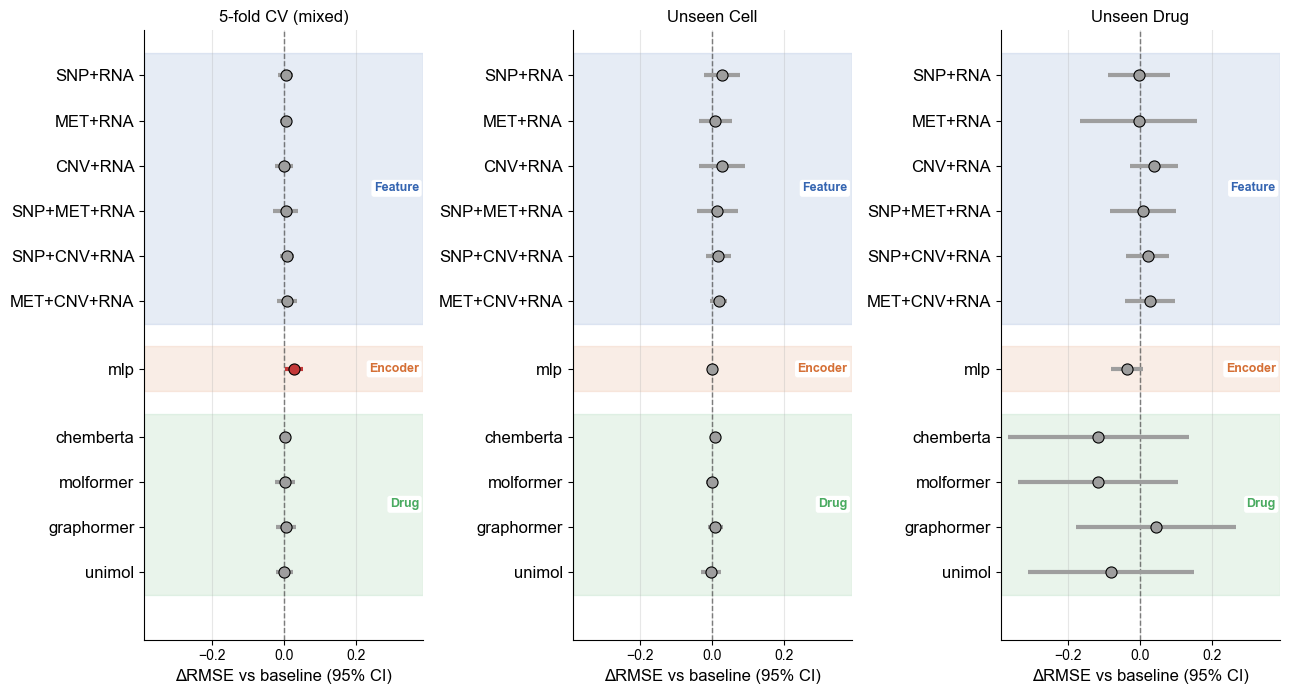

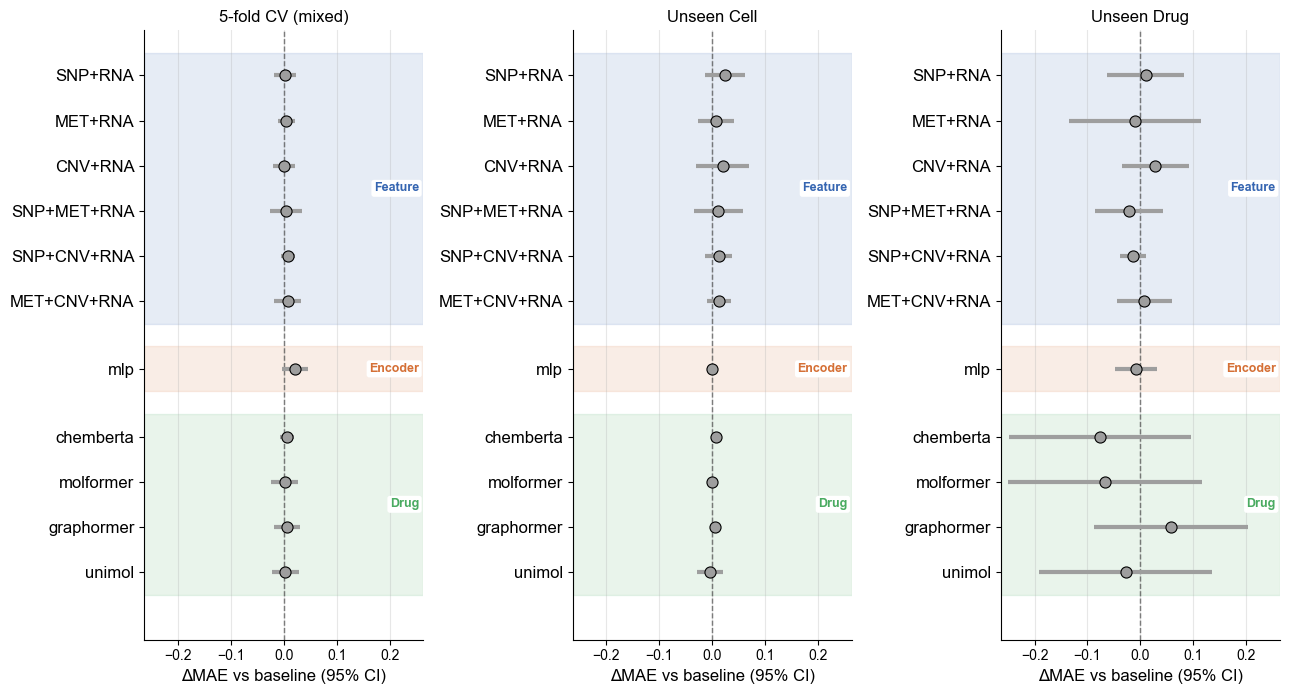

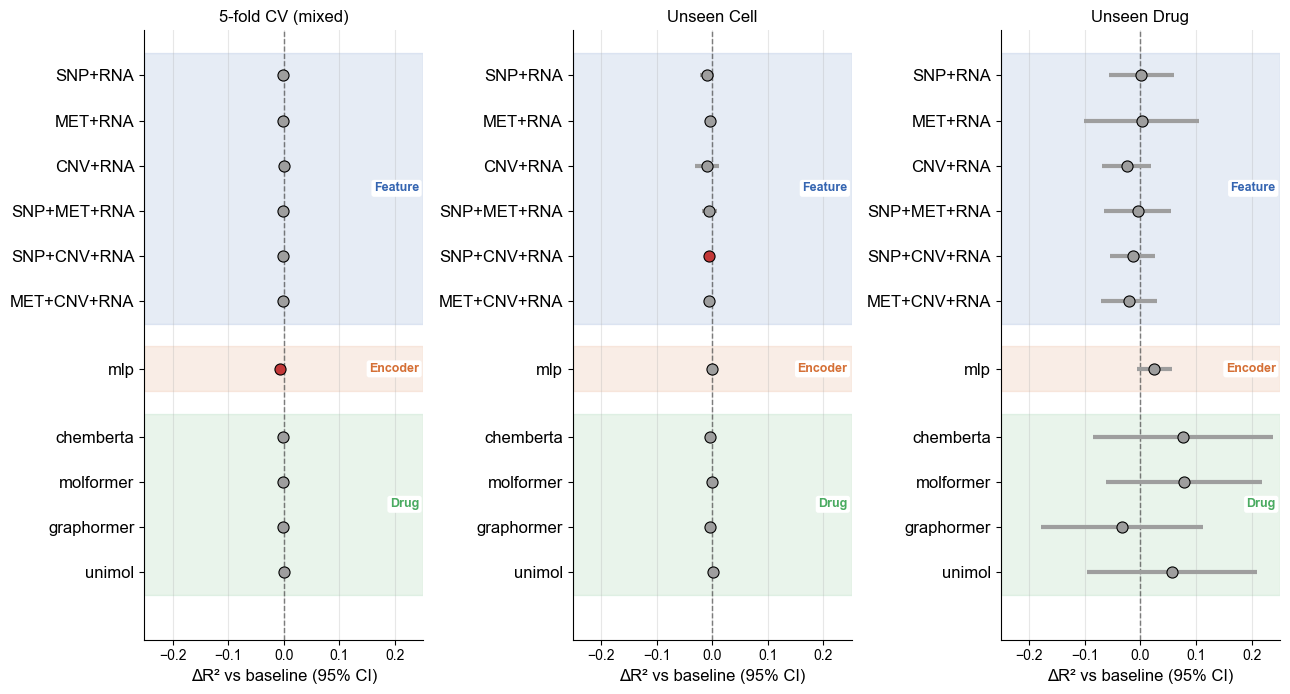

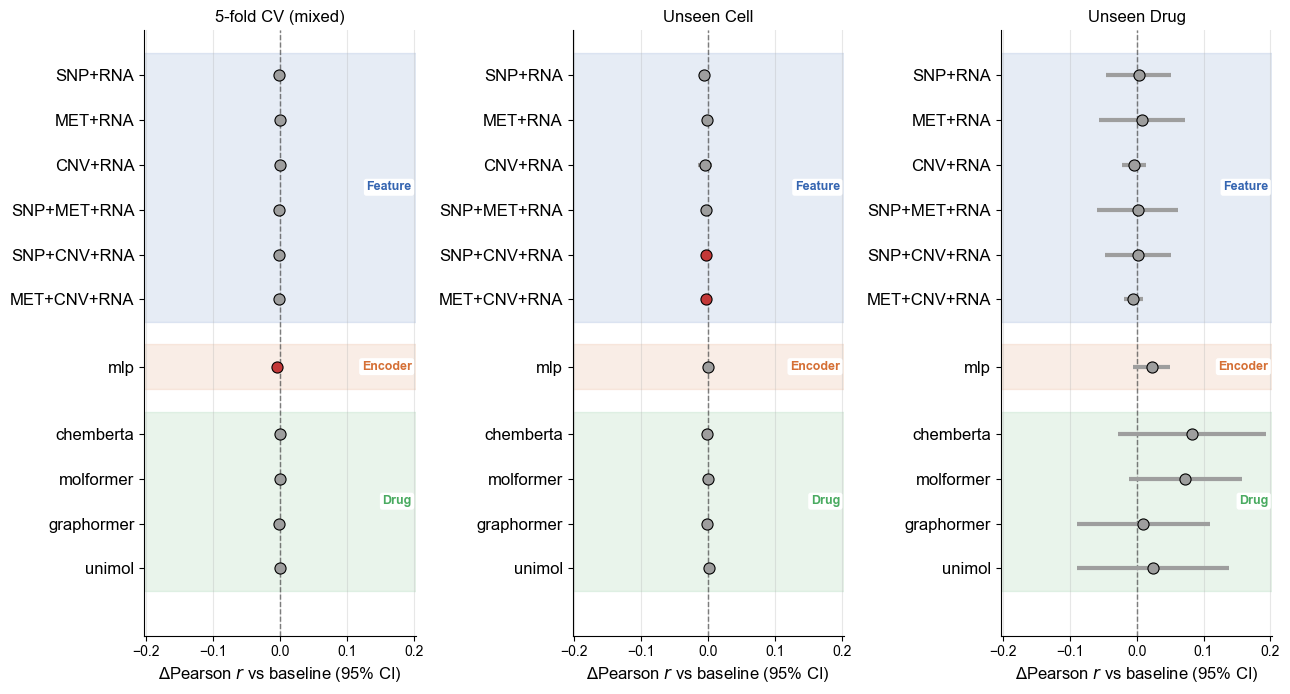

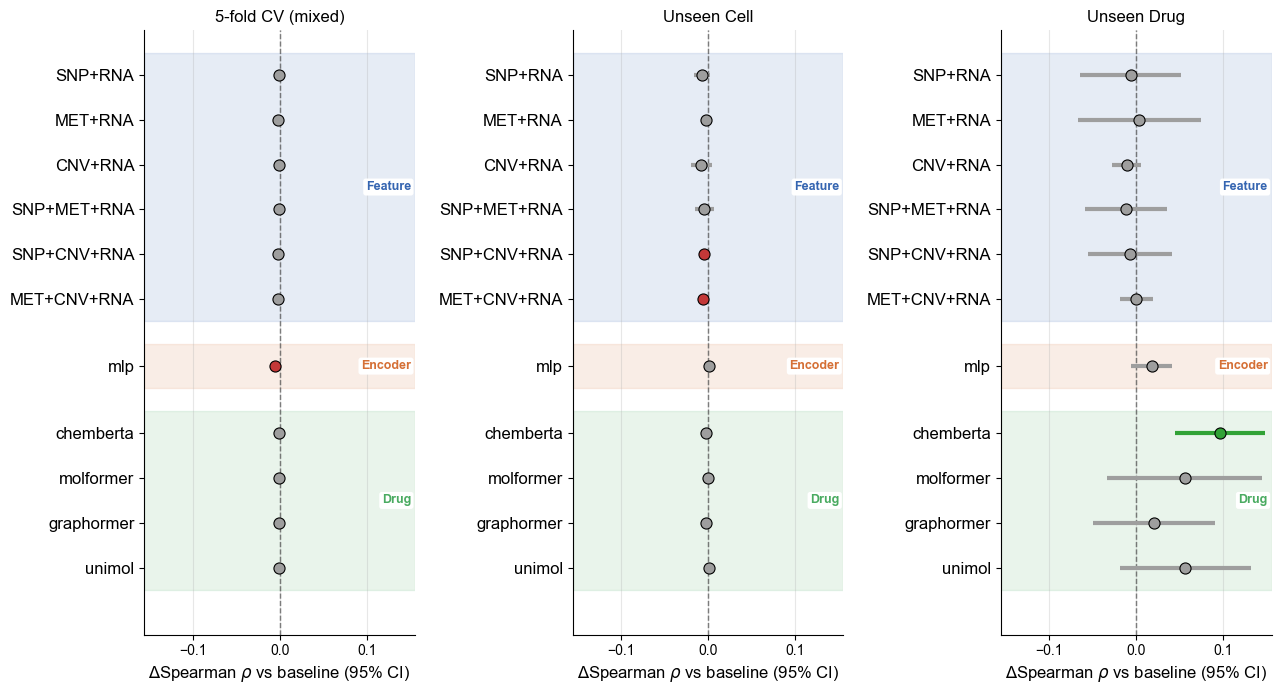

,split_mode,ablation,level,baseline,metric,mean_diff,ci_lo,ci_hi,verdict
0,mixed,omics,SNP+RNA,SNP+MET+CNV+RNA,rmse,0.005665,-0.015526,0.026856,inconclusive
1,mixed,omics,MET+RNA,SNP+MET+CNV+RNA,rmse,0.004784,-0.010856,0.020424,inconclusive
2,mixed,omics,CNV+RNA,SNP+MET+CNV+RNA,rmse,0.000978,-0.024139,0.026094,inconclusive
3,mixed,omics,SNP+MET+RNA,SNP+MET+CNV+RNA,rmse,0.004866,-0.029196,0.038928,inconclusive
4,mixed,omics,SNP+CNV+RNA,SNP+MET+CNV+RNA,rmse,0.008672,-0.009818,0.027162,inconclusive
...,...,...,...,...,...,...,...,...,...
160,unseen_drug,cell,mlp,attention,spearman,0.017725,-0.005541,0.040991,inconclusive
161,unseen_drug,drug,chemberta,morgan,spearman,0.096230,0.044381,0.148079,better
162,unseen_drug,drug,molformer,morgan,spearman,0.055482,-0.033662,0.144626,inconclusive
163,unseen_drug,drug,graphormer,morgan,spearman,0.020799,-0.049199,0.090798,inconclusive


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats

METRIC_LABEL = {'rmse': 'RMSE', 'mae': 'MAE', 'r2': 'R²', 'pearson': 'Pearson $r$', 'spearman': 'Spearman $\\rho$'}

BETTER_COLOR = "#31A236"    # CI entirely on the "better than baseline" side
WORSE_COLOR = "#C33838"     # CI entirely on the "worse than baseline" side
NEUTRAL_COLOR = '#9E9E9E'   # CI crosses zero -> inconclusive
BAND_COLOR = {'omics': "#3565B1", 'cell': "#D57036", 'drug': "#4AAB61"}
BAND_LABEL = {'omics': 'Feature', 'cell': 'Encoder', 'drug': 'Drug'}

# fixed row order per ablation group so the same condition sits at the same y-position in every column
LEVEL_ORDER = {
    'omics': ['SNP+RNA', 'MET+RNA', 'CNV+RNA', 'SNP+MET+RNA', 'SNP+CNV+RNA', 'MET+CNV+RNA'],
    'cell': ['mlp'],
    'drug': ['chemberta', 'molformer', 'graphormer', 'unimol'],
}

def paired_ci(vals, baseline_vals, conf=0.95):
    d = vals - baseline_vals
    n = len(d)
    mean_diff = d.mean()
    se = d.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(1 - (1 - conf) / 2, df=n - 1)
    return mean_diff, mean_diff - tcrit * se, mean_diff + tcrit * se


def collect_split_rows(sm, lower_better, metric):
    """All ablation-group rows for one split mode, grouped and ordered Feature -> Encoder -> Drug."""
    groups = []
    for vary, _ in ABLATIONS:
        fixed = {k: v for k, v in BASE.items() if k != vary}
        sub_folds = folds[folds['split_mode'] == sm]
        for k, v in fixed.items():
            sub_folds = sub_folds[sub_folds[k] == v]
        if sub_folds.empty:
            groups.append((vary, []))
            continue

        base_val = BASE[vary]
        baseline_vals = sub_folds[sub_folds[vary] == base_val].sort_values('fold')[metric].values
        levels = [lvl for lvl in sub_folds[vary].unique() if lvl != base_val]

        rows = []
        for lvl in levels:
            vals = sub_folds[sub_folds[vary] == lvl].sort_values('fold')[metric].values
            if len(vals) != len(baseline_vals):
                continue
            mean_diff, lo, hi = paired_ci(vals, baseline_vals)
            better = (hi < 0) if lower_better else (lo > 0)
            worse = (lo > 0) if lower_better else (hi < 0)
            color = BETTER_COLOR if better else (WORSE_COLOR if worse else NEUTRAL_COLOR)
            verdict = 'better' if better else ('worse' if worse else 'inconclusive')
            rows.append(dict(level=lvl, ablation=vary, mean_diff=mean_diff, lo=lo, hi=hi,
                              color=color, verdict=verdict))
        order_list = LEVEL_ORDER.get(vary)
        if order_list:
            rank = {lvl: k for k, lvl in enumerate(order_list)}
            rows.sort(key=lambda r: rank.get(r['level'], len(order_list)))
        else:
            rows.sort(key=lambda r: r['mean_diff'], reverse=not lower_better)
        groups.append((vary, rows))
    return groups


def plot_forest_grid(metric, lower_better):
    present_splits = [s for s in SPLIT_ORDER if s in folds['split_mode'].unique()]

    split_groups = {sm: collect_split_rows(sm, lower_better, metric) for sm in present_splits}
    max_rows = max(sum(len(rows) for _, rows in split_groups[sm]) + (len(ABLATIONS) - 1)
                    for sm in present_splits)

    fig_bound = 0.0
    for sm in present_splits:
        for _, rows in split_groups[sm]:
            for r in rows:
                fig_bound = max(fig_bound, abs(r['lo']), abs(r['hi']))
    xlim = (-1.05 * fig_bound, 1.05 * fig_bound) if fig_bound > 0 else (-1, 1)

    fig, axes = plt.subplots(1, len(present_splits),
                              figsize=(13, 8), squeeze=False)
    ci_rows = []

    for j, sm in enumerate(present_splits):
        ax = axes[0][j]
        y_cursor = 0
        yticks, yticklabels = [], []
        for vary, rows in split_groups[sm]:
            if not rows:
                continue
            band_top = y_cursor + len(rows)
            ax.axhspan(y_cursor - 0.5, band_top - 0.5, color=BAND_COLOR[vary], alpha=0.12, zorder=0)
            ax.text(xlim[1] * 0.97, (y_cursor + band_top) / 2 - 0.5, BAND_LABEL[vary],
                    ha='right', va='center', fontsize=9, fontweight='bold',
                    color=BAND_COLOR[vary], rotation=0,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none'))
            for k, r in enumerate(rows):
                yy = y_cursor + k
                ax.plot([r['lo'], r['hi']], [yy, yy], color=r['color'], linewidth=3, solid_capstyle='butt', zorder=2)
                ax.plot(r['mean_diff'], yy, 'o', color=r['color'], markersize=8, zorder=3,
                        markeredgecolor='black', markeredgewidth=0.8)
                yticks.append(yy)
                yticklabels.append(r['level'])
                ci_rows.append({'split_mode': sm, 'ablation': vary, 'level': r['level'],
                                 'baseline': BASE[vary], 'metric': metric, 'mean_diff': r['mean_diff'],
                                 'ci_lo': r['lo'], 'ci_hi': r['hi'], 'verdict': r['verdict']})
            y_cursor = band_top + 0.5

        ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6, zorder=1)
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=12)
        ax.set_ylim(-1, y_cursor)
        ax.invert_yaxis()
        ax.set_xlim(*xlim)
        ax.set_title(SPLIT_LABEL[sm], fontsize=12)
        ax.set_xlabel(f'Δ{METRIC_LABEL[metric]} vs baseline (95% CI)', fontsize=12)
        ax.grid(axis='x', alpha=0.3, zorder=0)

    fig.tight_layout(rect=(0, 0, 1, 0.88))
    os.makedirs('outputs', exist_ok=True)
    fig.savefig(f'outputs/forest_grid_{metric}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return pd.DataFrame(ci_rows)


all_ci = []
for metric, lower_better in METRICS_TO_PLOT.items():
    ci_df = plot_forest_grid(metric, lower_better)
    all_ci.append(ci_df)

ci_df = pd.concat(all_ci, ignore_index=True)
ci_df.to_csv('outputs/ablation_paired_ci.csv', index=False)
ci_df


## Competitor benchmark table (nested CV)

In [ ]:
BENCH_DIR = Path(RESULTS_DIR).parents[1] / 'benchmark' / 'BenchmarkResults'
BASELINE_TAGS = {
    'mixed': 'SNP+MET+CNV+RNA__attention__morgan__mixed__c94ea3',
    'unseen_cell': 'SNP+MET+CNV+RNA__attention__morgan__unseen_cell__f89c87',
    'unseen_drug': 'SNP+MET+CNV+RNA__attention__morgan__unseen_drug__cd5222',
}
BENCH_METRICS = ['rmse', 'r2', 'pearson', 'spearman']

def omicsdrp_n_params(tag):
    events_path = Path(RESULTS_DIR) / tag / 'events.jsonl'
    if not events_path.exists():
        return None
    for line in open(events_path):
        d = json.loads(line)
        if d.get('kind') == 'model_info':
            return d['n_params']
    return None

def bench_rows():
    rows = []
    for model_dir in sorted(BENCH_DIR.glob('*')):
        for split_dir in sorted(model_dir.glob('nested__*')):
            fold_metrics = [json.load(open(p)) for p in sorted(split_dir.glob('fold_*/metrics.json'))]
            if not fold_metrics:
                continue
            rec = {'model': model_dir.name, 'split_mode': split_dir.name.replace('nested__', ''),
                   'n_folds': len(fold_metrics), 'n_params': fold_metrics[0].get('n_params_total')}
            for m in BENCH_METRICS:
                vals = [f[m] for f in fold_metrics if m in f]
                rec[f'{m}_mean'] = np.mean(vals)
                rec[f'{m}_std'] = np.std(vals)
            rows.append(rec)
    for split_mode, tag in BASELINE_TAGS.items():
        p = Path(RESULTS_DIR) / tag / 'summary.json'
        if not p.exists():
            continue
        s = json.load(open(p))
        rec = {'model': 'omicsdrp', 'split_mode': split_mode, 'n_folds': s.get('n_folds'),
               'n_params': omicsdrp_n_params(tag)}
        for m in BENCH_METRICS:
            rec[f'{m}_mean'] = s.get(f'{m}_mean')
            rec[f'{m}_std'] = s.get(f'{m}_std')
        rows.append(rec)
    return pd.DataFrame(rows)

bench = bench_rows()
bench = bench.sort_values(['split_mode', 'rmse_mean']).reset_index(drop=True)
os.makedirs('outputs', exist_ok=True)
bench.to_csv('outputs/benchmark_summary.csv', index=False)
print('saved:', os.path.abspath('outputs/benchmark_summary.csv'))
bench

NameError: name 'Path' is not defined